# SEIRS-SEI Malaria Model — Force of Infection Calibration

Calibrating **b1** (human to mosquito transmission) and **b2** (mosquito to human transmission) to fit model I_H to observed active cases.

Uses the optimal **M'** found in `SEIRS_SEI_ODE_Mprime_Calibration.ipynb` as a fixed parameter and the initial conditions fitted in `SEIRS_SEI_ODE_IC_Calibration.ipynb`.

**Parameters being calibrated:**
- **b1**: scaling factor for mosquito FoI (foi_m = a * b1 * I_H/N)
- **b2**: scaling factor for human FoI (foi_h = a * b2 * I_M/N)

**Fixed**: M' = optimal value from Mprime calibration, all other parameters at defaults from shared.py.


In [2]:
from seirs_sei_ode_shared import *
%matplotlib inline

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Pop data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


In [3]:
#### Updating initial conditions:

rural_cases_df = cases_data.copy()
cols = [
    "active_total",
    "active_symptomatic",
    "active_asymptomatic",
    "new_cases",
    "cumulative_cases",
    "active_per_new_case",
]
rural_cases_df[cols] = rural_cases_df[cols] * (41.54 / 100)
I_H0 = round(rural_cases_df["active_total"].iloc[0])
N_2017 = round(pop_by_year[2017])

E_H0 = round(N_2017 * 0.05) #418
R_H0 = round(N_2017 * 0.05) #418
S_H0 = N_2017 - E_H0 - I_H0 - R_H0

M_0 = 10 * N_2017
I_M0 = round(M_0 * 0.02) #1674
E_M0 = round(I_M0 * 3)
S_M0 = M_0 - E_M0 - I_M0
initial_state_2017 = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])

print(
    f"Initial human compartments in 2017: N={N_2017}, S_H={S_H0}, E_H={E_H0}, I_H={I_H0}, R_H={R_H0}"
)
print(
    f"Initial mosquito compartments in 2017: M={M_0}, S_M={S_M0}, E_M={E_M0}, I_M={I_M0}"
)

Initial human compartments in 2017: N=8369, S_H=6589, E_H=418, I_H=944, R_H=418
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


---
## Section 1: Calibration without Climate Smoothing

Uses optimal M' ~ 55.99 * N from Mprime calibration (no-smoothing run).


In [5]:
#### Yearly Simulation (2017-2023) - No Smoothing
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

USE_SMOOTH_CLIMATE = False
M_PRIME_FIXED = 55.99 * N_2017

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")

    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD,
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_PRIME_FIXED, tau_H, omega,
                            M_min=M_min, permanent_factor=permanent_factor,
                            use_smooth_climate=USE_SMOOTH_CLIMATE)

    sol = solve_ivp(ode_func, [0, num_days], current_state,
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')

    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")



Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 637, Final I_M: 501

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 315, Final I_M: 118

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 325, Final I_M: 292

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 211, Final I_M: 128

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 363, Final I_M: 225

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 234, Final I_M: 32

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 83, Final I_M: 26

All years simulated successfully!


In [6]:
def run_simulation_with_b1_b2(b1_val, b2_val, initial_state=None):
    if initial_state is None:
        init_state = initial_state_2017.copy()
    else:
        init_state = initial_state.copy()
    all_IH = []
    all_dates = []
    current_state = init_state
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
        if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        def ode_func(t, z):
            return seirs_sei_ode(t, z, N, year_climate,
                                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                                c1, c2, D1, b1_val, b2_val, A, B, C, DD,
                                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                                gamma, R_L, M_PRIME_FIXED, tau_H, omega,
                                M_min=M_min, permanent_factor=permanent_factor,
                                use_smooth_climate=USE_SMOOTH_CLIMATE)
        sol = solve_ivp(ode_func, [0, num_days], current_state,
                        t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
        if not sol.success:
            return np.array([]), np.array([])
        current_state = sol.y[:, -1].copy()
        current_state = np.maximum(current_state, 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)


In [7]:
def objective_function(log_params):
    log_b1, log_b2 = log_params
    b1_test = np.exp(log_b1)
    b2_test = np.exp(log_b2)
    if b1_test < 0.0001 or b1_test > 5.0:
        return 1e15
    if b2_test < 0.0001 or b2_test > 5.0:
        return 1e15
    dates, IH = run_simulation_with_b1_b2(b1_test, b2_test)
    if len(dates) == 0:
        return 1e15
    model_interp = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse


In [8]:
print("Grid search for b1 and b2 (no smoothing)...")

b1_candidates = [0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.30, 0.45]
b2_candidates = [0.01, 0.03, 0.06, 0.09, 0.15, 0.25, 0.40, 0.60]

grid_results = []
for b1_test in b1_candidates:
    for b2_test in b2_candidates:
        mse = objective_function([np.log(b1_test), np.log(b2_test)])
        grid_results.append((b1_test, b2_test, mse))
        print(f"  b1={b1_test:<6.3f}  b2={b2_test:<6.3f}  -> MSE={mse:>15,.2f}")

grid_results.sort(key=lambda x: x[2])
best_b1_grid, best_b2_grid, best_mse_grid = grid_results[0]
print(f"\nBest from grid: b1={best_b1_grid:.4f}, b2={best_b2_grid:.4f}  (MSE={best_mse_grid:,.2f})")


Grid search for b1 and b2 (no smoothing)...
  b1=0.005   b2=0.010   -> MSE=     601,577.19
  b1=0.005   b2=0.030   -> MSE=     593,445.74
  b1=0.005   b2=0.060   -> MSE=     581,710.78
  b1=0.005   b2=0.090   -> MSE=     570,693.78
  b1=0.005   b2=0.150   -> MSE=     551,834.76
  b1=0.005   b2=0.250   -> MSE=     533,422.32
  b1=0.005   b2=0.400   -> MSE=     538,634.14
  b1=0.005   b2=0.600   -> MSE=     559,941.47
  b1=0.010   b2=0.010   -> MSE=     599,433.61
  b1=0.010   b2=0.030   -> MSE=     586,419.38
  b1=0.010   b2=0.060   -> MSE=     566,026.53
  b1=0.010   b2=0.090   -> MSE=     545,793.43
  b1=0.010   b2=0.150   -> MSE=     506,460.24
  b1=0.010   b2=0.250   -> MSE=     453,661.97
  b1=0.010   b2=0.400   -> MSE=     496,635.75
  b1=0.010   b2=0.600   -> MSE=   1,111,189.55
  b1=0.020   b2=0.010   -> MSE=     594,949.63
  b1=0.020   b2=0.030   -> MSE=     570,874.08
  b1=0.020   b2=0.060   -> MSE=     528,976.04
  b1=0.020   b2=0.090   -> MSE=     481,998.98
  b1=0.020   b2=

In [9]:
print("Fine optimization with L-BFGS-B...")
from scipy.optimize import minimize

initial_guess = [np.log(best_b1_grid), np.log(best_b2_grid)]

result = minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',
    options={'maxiter': 100, 'ftol': 1e-8}
)

b1_optimal = np.exp(result.x[0])
b2_optimal = np.exp(result.x[1])
print(f"Optimal b1 = {b1_optimal:.6f}")
print(f"Optimal b2 = {b2_optimal:.6f}")
print(f"Optimal MSE = {result.fun:,.2f}")


Fine optimization with L-BFGS-B...
Optimal b1 = 0.040000
Optimal b2 = 0.090000
Optimal MSE = 295,767.29


Final simulation with optimal b1, b2 (no smoothing)...


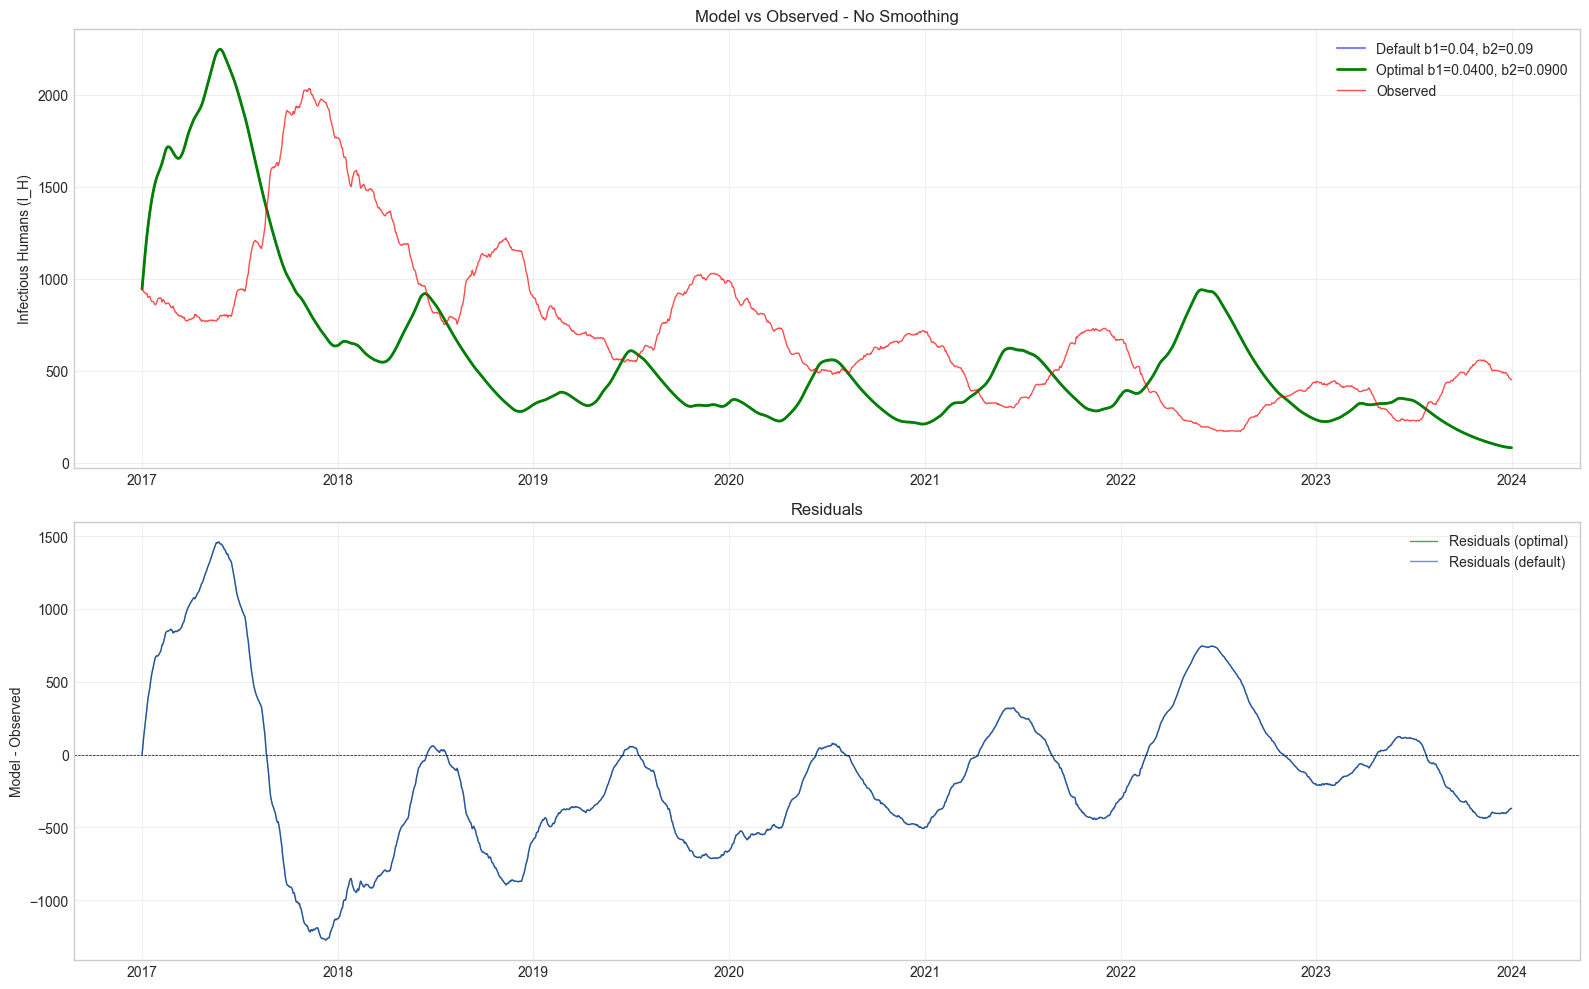


Calibration Summary (No Smoothing)
  Fixed M′ = 468,580  (55.99 x N)
  Default b1 = 0.04, b2 = 0.09
  Optimal b1 = 0.040000
  Optimal b2 = 0.090000
  Default MSE = 295,869.27
  Optimal MSE = 295,767.29


In [10]:
print("Final simulation with optimal b1, b2 (no smoothing)...")
dates_opt, IH_opt = run_simulation_with_b1_b2(b1_optimal, b2_optimal)

# Baseline: run with default b1, b2
dates_base, IH_base = run_simulation_with_b1_b2(b1, b2)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_base), IH_base, 'b-', linewidth=1.5, alpha=0.5,
         label=f"Default b1={b1}, b2={b2}")
ax1.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=2,
         label=f"Optimal b1={b1_optimal:.4f}, b2={b2_optimal:.4f}")
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Model vs Observed - No Smoothing')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals
ax2 = axes[1]
residuals_opt = IH_opt - rural_cases_df['active_total'].values
residuals_base = IH_base - rural_cases_df['active_total'].values
ax2.plot(pd.to_datetime(dates_opt), residuals_opt, 'g-', linewidth=1.0, alpha=0.7, label='Residuals (optimal)')
ax2.plot(pd.to_datetime(dates_base), residuals_base, 'b-', linewidth=1.0, alpha=0.5, label='Residuals (default)')
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Model - Observed')
ax2.set_title('Residuals')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCalibration Summary (No Smoothing)")
print(f"  Fixed M\u2032 = {M_PRIME_FIXED:,.0f}  ({M_PRIME_FIXED/N_2017:.2f} x N)")
print(f"  Default b1 = {b1}, b2 = {b2}")
print(f"  Optimal b1 = {b1_optimal:.6f}")
print(f"  Optimal b2 = {b2_optimal:.6f}")
base_mse = np.mean((IH_base - rural_cases_df["active_total"].values) ** 2)
print(f"  Default MSE = {base_mse:,.2f}")
print(f"  Optimal MSE = {result.fun:,.2f}")


---
## Section 2: Calibration with Climate Smoothing

Uses optimal M' ~ 44.86 * N from Mprime calibration (with-smoothing run).


In [12]:
#### Yearly Simulation (2017-2023) - With Smoothing
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

USE_SMOOTH_CLIMATE = True
M_PRIME_FIXED = 44.86 * N_2017

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")

    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD,
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_PRIME_FIXED, tau_H, omega,
                            M_min=M_min, permanent_factor=permanent_factor,
                            use_smooth_climate=USE_SMOOTH_CLIMATE)

    sol = solve_ivp(ode_func, [0, num_days], current_state,
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')

    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")



Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 641, Final I_M: 305

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 251, Final I_M: 152

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 239, Final I_M: 139

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 167, Final I_M: 75

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 250, Final I_M: 160

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 177, Final I_M: 27

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 79, Final I_M: 10

All years simulated successfully!


In [13]:
def run_simulation_with_b1_b2(b1_val, b2_val, initial_state=None):
    if initial_state is None:
        init_state = initial_state_2017.copy()
    else:
        init_state = initial_state.copy()
    all_IH = []
    all_dates = []
    current_state = init_state
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
        if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        def ode_func(t, z):
            return seirs_sei_ode(t, z, N, year_climate,
                                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                                c1, c2, D1, b1_val, b2_val, A, B, C, DD,
                                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                                gamma, R_L, M_PRIME_FIXED, tau_H, omega,
                                M_min=M_min, permanent_factor=permanent_factor,
                                use_smooth_climate=USE_SMOOTH_CLIMATE)
        sol = solve_ivp(ode_func, [0, num_days], current_state,
                        t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
        if not sol.success:
            return np.array([]), np.array([])
        current_state = sol.y[:, -1].copy()
        current_state = np.maximum(current_state, 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)


In [14]:
print("Grid search for b1 and b2 (with smoothing)...")

grid_results = []
for b1_test in b1_candidates:
    for b2_test in b2_candidates:
        mse = objective_function([np.log(b1_test), np.log(b2_test)])
        grid_results.append((b1_test, b2_test, mse))
        print(f"  b1={b1_test:<6.3f}  b2={b2_test:<6.3f}  -> MSE={mse:>15,.2f}")

grid_results.sort(key=lambda x: x[2])
best_b1_grid, best_b2_grid, best_mse_grid = grid_results[0]
print(f"\nBest from grid: b1={best_b1_grid:.4f}, b2={best_b2_grid:.4f}  (MSE={best_mse_grid:,.2f})")


Grid search for b1 and b2 (with smoothing)...
  b1=0.005   b2=0.010   -> MSE=     600,672.18
  b1=0.005   b2=0.030   -> MSE=     590,978.84
  b1=0.005   b2=0.090   -> MSE=     566,419.92
  b1=0.005   b2=0.150   -> MSE=     551,286.81
  b1=0.005   b2=0.250   -> MSE=     552,742.45
  b1=0.005   b2=0.400   -> MSE=     607,327.96
  b1=0.005   b2=0.600   -> MSE=     693,749.44
  b1=0.010   b2=0.010   -> MSE=     598,198.96
  b1=0.010   b2=0.030   -> MSE=     583,024.27
  b1=0.010   b2=0.060   -> MSE=     561,010.82
  b1=0.010   b2=0.090   -> MSE=     541,288.41
  b1=0.010   b2=0.150   -> MSE=     515,624.50
  b1=0.010   b2=0.250   -> MSE=     517,873.65
  b1=0.010   b2=0.400   -> MSE=     590,036.00
  b1=0.010   b2=0.600   -> MSE=   1,199,326.78
  b1=0.020   b2=0.010   -> MSE=     593,148.20
  b1=0.020   b2=0.030   -> MSE=     566,117.07
  b1=0.020   b2=0.060   -> MSE=     524,840.41
  b1=0.020   b2=0.090   -> MSE=     488,389.19
  b1=0.020   b2=0.150   -> MSE=     430,923.51
  b1=0.020   b

In [15]:
print("Fine optimization with L-BFGS-B (with smoothing)...")

initial_guess = [np.log(best_b1_grid), np.log(best_b2_grid)]

result_smooth = minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',
    options={'maxiter': 100, 'ftol': 1e-8}
)

b1_optimal_smooth = np.exp(result_smooth.x[0])
b2_optimal_smooth = np.exp(result_smooth.x[1])
print(f"Optimal b1 = {b1_optimal_smooth:.6f}")
print(f"Optimal b2 = {b2_optimal_smooth:.6f}")
print(f"Optimal MSE = {result_smooth.fun:,.2f}")


Fine optimization with L-BFGS-B (with smoothing)...
Optimal b1 = 0.423055
Optimal b2 = 0.009364
Optimal MSE = 296,758.00


Final simulation with optimal b1, b2 (with smoothing)...


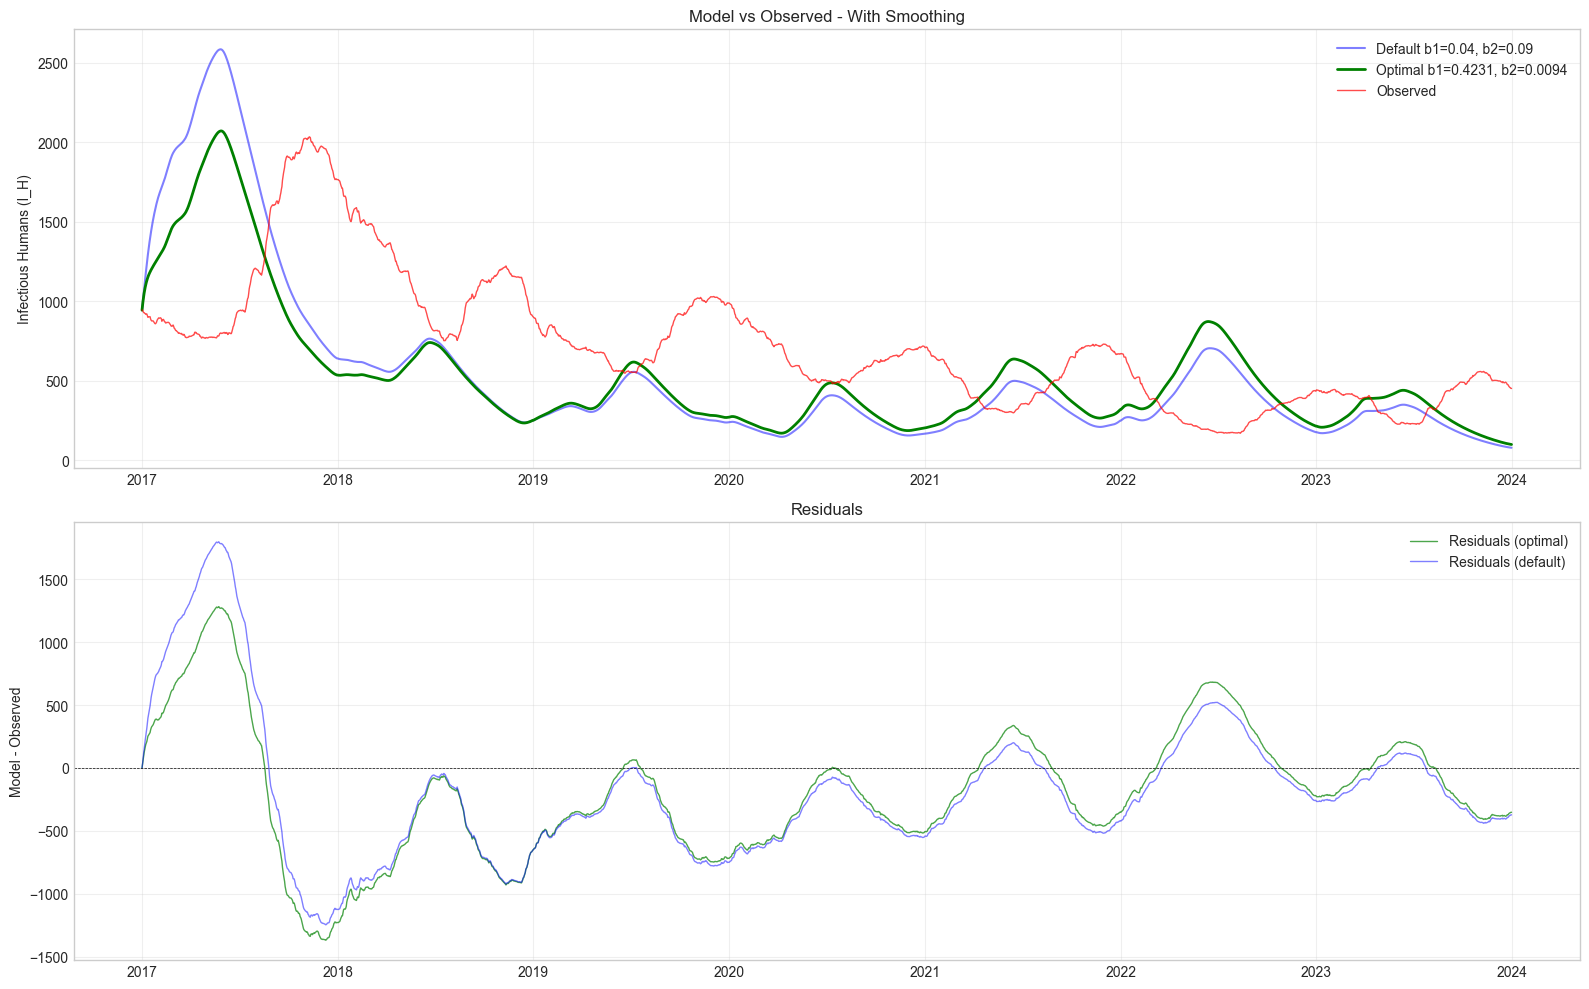


Calibration Summary (With Smoothing)
  Fixed M′ = 375,433  (44.86 x N)
  Default b1 = 0.04, b2 = 0.09
  Optimal b1 = 0.423055
  Optimal b2 = 0.009364
  Default MSE = 353,561.34
  Optimal MSE = 296,758.00


In [16]:
print("Final simulation with optimal b1, b2 (with smoothing)...")
dates_opt, IH_opt = run_simulation_with_b1_b2(b1_optimal_smooth, b2_optimal_smooth)
dates_base, IH_base = run_simulation_with_b1_b2(b1, b2)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_base), IH_base, 'b-', linewidth=1.5, alpha=0.5,
         label=f"Default b1={b1}, b2={b2}")
ax1.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=2,
         label=f"Optimal b1={b1_optimal_smooth:.4f}, b2={b2_optimal_smooth:.4f}")
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Model vs Observed - With Smoothing')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
residuals_opt = IH_opt - rural_cases_df['active_total'].values
residuals_base = IH_base - rural_cases_df['active_total'].values
ax2.plot(pd.to_datetime(dates_opt), residuals_opt, 'g-', linewidth=1.0, alpha=0.7, label='Residuals (optimal)')
ax2.plot(pd.to_datetime(dates_base), residuals_base, 'b-', linewidth=1.0, alpha=0.5, label='Residuals (default)')
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Model - Observed')
ax2.set_title('Residuals')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCalibration Summary (With Smoothing)")
print(f"  Fixed M\u2032 = {M_PRIME_FIXED:,.0f}  ({M_PRIME_FIXED/N_2017:.2f} x N)")
print(f"  Default b1 = {b1}, b2 = {b2}")
print(f"  Optimal b1 = {b1_optimal_smooth:.6f}")
print(f"  Optimal b2 = {b2_optimal_smooth:.6f}")
base_mse = np.mean((IH_base - rural_cases_df["active_total"].values) ** 2)
print(f"  Default MSE = {base_mse:,.2f}")
print(f"  Optimal MSE = {result_smooth.fun:,.2f}")
